In [1]:
#STEP-1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#STEP-2
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


In [4]:
#STEP-3
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


In [6]:
#STEP-4
file_path = "/content/drive/MyDrive/ColabData/FYDP/uav_ids_shap_pigen_lightweight.csv"
df = pd.read_csv(file_path)

df.head()

,timestamp_c,ip.len_x,wlan.duration_x,udp.dstport_x,ip.hdr_len_x,frame.number_x,wlan.fc.type_x,tcp.dstport_x,tcp.window_size_x,frame.len_x,class
0,1.895610,3.297311,-1.141609,-0.434148,2.651215,1.768777,-0.000034,1.647751,-0.228266,1.911806,2
1,-0.525989,-0.455020,1.072081,-0.434148,-0.617717,-0.440201,-1.062099,-0.591532,-0.231674,-0.733782,1
2,-0.525982,-0.455020,-0.730090,-0.434148,-0.617717,-0.069206,1.202272,-0.591532,-0.231674,-0.733782,1
3,-0.525989,-0.455020,1.072081,-0.434148,-0.617717,-0.376788,-1.062099,-0.591532,-0.231674,-0.733782,1
4,-0.525982,-0.455020,1.072081,-0.434148,-0.617717,0.111945,-1.062099,-0.591532,-0.231674,-0.733782,4


In [7]:
#STEP-5
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nClass distribution:")
print(df["class"].value_counts().sort_index())
print("\nMissing values:")
print(df.isnull().sum())


Shape: (36743, 11)
Columns: ['timestamp_c', 'ip.len_x', 'wlan.duration_x', 'udp.dstport_x', 'ip.hdr_len_x', 'frame.number_x', 'wlan.fc.type_x', 'tcp.dstport_x', 'tcp.window_size_x', 'frame.len_x', 'class']

Class distribution:
class
0    6723
1    8170
2    6723
3    6723
4    8404
Name: count, dtype: int64

Missing values:
timestamp_c          0
ip.len_x             0
wlan.duration_x      0
udp.dstport_x        0
ip.hdr_len_x         0
frame.number_x       0
wlan.fc.type_x       0
tcp.dstport_x        0
tcp.window_size_x    0
frame.len_x          0
class                0
dtype: int64


In [8]:
#STEP-6
target_col = "class"

# Sort by timestamp so LSTM sees ordered samples
df = df.sort_values("timestamp_c").reset_index(drop=True)

feature_cols = [col for col in df.columns if col != target_col]

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df[target_col].values.astype(np.int64)

print("Feature columns:", feature_cols)
print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)


Feature columns: ['timestamp_c', 'ip.len_x', 'wlan.duration_x', 'udp.dstport_x', 'ip.hdr_len_x', 'frame.number_x', 'wlan.fc.type_x', 'tcp.dstport_x', 'tcp.window_size_x', 'frame.len_x']
X shape: (36743, 10)
y shape: (36743,)


In [9]:
#STEP-7
def build_sequences(features, labels, window_size=8):
    X_seq, y_seq = [], []

    for end_idx in range(window_size - 1, len(features)):
        start_idx = end_idx - window_size + 1
        X_seq.append(features[start_idx:end_idx + 1])
        y_seq.append(labels[end_idx])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64)

window_size = 8
X, y = build_sequences(X_raw, y_raw, window_size=window_size)

print("Sequence X shape:", X.shape)  # (samples, time_steps, features)
print("Sequence y shape:", y.shape)


Sequence X shape: (36736, 8, 10)
Sequence y shape: (36736,)


In [10]:
#STEP-8
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (25715, 8, 10) (25715,)
Test shape: (11021, 8, 10) (11021,)


In [11]:
#STEP-9
batch_size = 128

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [28]:
#STEP-10
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last time step
        out = self.classifier(out)
        return out

input_size = X.shape[2]
hidden_size = 64
num_layers = 2
num_classes = len(np.unique(y))

model = LSTMClassifier(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=0.3
).to(device)

print(model)



LSTMClassifier(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [13]:
#STEP-11
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [14]:
#STEP-12
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        outputs = model(xb)
        loss = criterion(outputs, yb)

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)


In [30]:
#STEP-13
epochs = 15
best_acc = 0
best_model_path = "/content/best_lstm_uav_model.pt"

history = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")
    print("-" * 50)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), best_model_path)

print("Best Test Accuracy:", best_acc)


Epoch 1/15
Train Loss: 2.0608 | Train Acc: 0.1369
Test  Loss: 2.0232 | Test  Acc: 0.1679
--------------------------------------------------
Epoch 2/15
Train Loss: 2.0615 | Train Acc: 0.1380
Test  Loss: 2.0232 | Test  Acc: 0.1679
--------------------------------------------------
Epoch 3/15
Train Loss: 2.0645 | Train Acc: 0.1340
Test  Loss: 2.0232 | Test  Acc: 0.1679
--------------------------------------------------
Epoch 4/15
Train Loss: 2.0665 | Train Acc: 0.1336
Test  Loss: 2.0232 | Test  Acc: 0.1679
--------------------------------------------------
Epoch 5/15
Train Loss: 2.0698 | Train Acc: 0.1332
Test  Loss: 2.0232 | Test  Acc: 0.1679
--------------------------------------------------
Epoch 6/15
Train Loss: 2.0658 | Train Acc: 0.1358
Test  Loss: 2.0232 | Test  Acc: 0.1679
--------------------------------------------------
Epoch 7/15
Train Loss: 2.0621 | Train Acc: 0.1363
Test  Loss: 2.0232 | Test  Acc: 0.1679
--------------------------------------------------
Epoch 8/15
Train Los

In [31]:
#STEP-14
model.load_state_dict(torch.load(best_model_path))
print(" model loaded successfully.")


 model loaded successfully.


In [ ]:
#STEP-15
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print("Final Test Accuracy:", test_acc)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))


Final Test Accuracy: 0.8332274748207966

Classification Report:

              precision    recall  f1-score   support

           0     0.8635    0.9757    0.9162      2017
           1     0.6151    0.8862    0.7262      2451
           2     1.0000    1.0000    1.0000      2017
           3     1.0000    1.0000    1.0000      2017
           4     0.8573    0.4006    0.5460      2519

    accuracy                         0.8332     11021
   macro avg     0.8672    0.8525    0.8377     11021
weighted avg     0.8568    0.8332    0.8200     11021


Confusion Matrix:

[[1968   29    0    0   20]
 [ 131 2172    0    0  148]
 [   0    0 2017    0    0]
 [   0    0    0 2017    0]
 [ 180 1330    0    0 1009]]


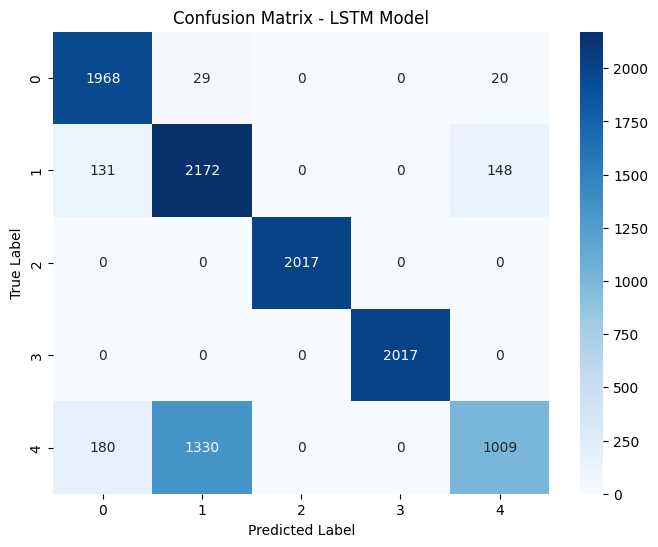

In [22]:
#STEP-16
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM Model")
plt.show()


In [24]:
#STEP-17
final_model_path = "/content/lstm_uav.pth"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_size": input_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "num_classes": num_classes,
    "window_size": window_size,
    "feature_columns": feature_cols
}

torch.save(checkpoint, final_model_path)
print("Model checkpoint saved at:", final_model_path)


Model checkpoint saved at: /content/lstm_uav.pth


In [20]:
#STEP-18
history_path = "/content/lstm_training_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print("Training history saved at:", history_path)


Training history saved at: /content/lstm_training_history.json


In [26]:
#STEP-19
from google.colab import files

files.download("/content/best_lstm_uav_model.pt")
files.download("/content/lstm_uav_full_checkpoint.pth")
files.download("/content/lstm_training_history.json")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>